t :  xi(t)
 0 :  3
 1 :  4
 2 :  5
 3 :  4
 4 :  1
 5 :  4
 6 :  5
 7 :  4
 8 :  1
 9 :  3
10 :  3
11 :  5
12 :  4
13 :  5
14 :  2
15 :  3
16 :  5
17 :  1
18 :  4
19 :  3
20 :  5
21 :  2
22 :  5
23 :  4
24 :  5
25 :  1
26 :  3
27 :  1
28 :  2
29 :  4
30 :  5


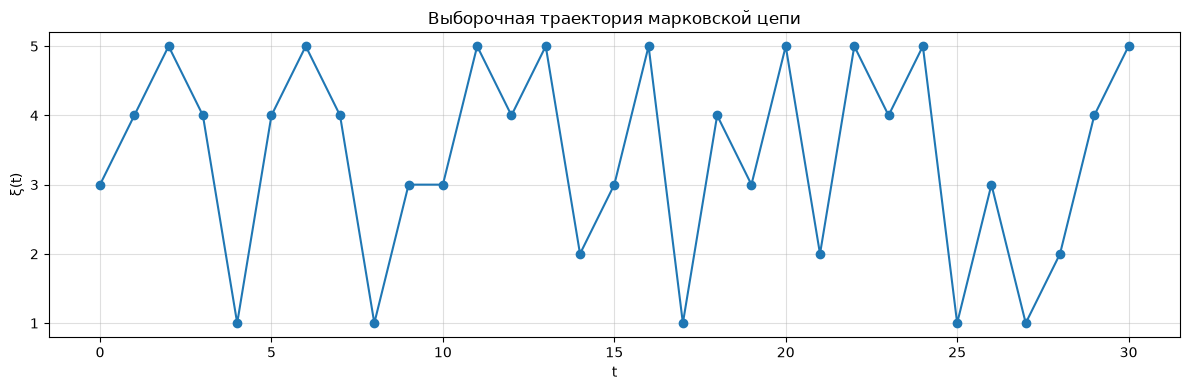

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Дано
# -----------------------------
# Пространство состояний S = {1, 2, 3, 4, 5}
states = np.array([1, 2, 3, 4, 5])

# Начальное распределение pi
pi = np.array([0.0, 0.2, 0.6, 0.0, 0.2])

# Матрица переходных вероятностей P
P = np.array([
    [0.1, 0.2, 0.3, 0.4, 0.0],
    [0.0, 0.2, 0.2, 0.3, 0.3],
    [0.3, 0.0, 0.1, 0.1, 0.5],
    [0.4, 0.1, 0.2, 0.0, 0.3],
    [0.2, 0.3, 0.1, 0.4, 0.0],
])

# Моменты времени
T = np.arange(0, 31)  # t = 0, 1, ..., 30

# -----------------------------
# Генерация траектории
# -----------------------------
def generate_trajectory(pi, P, T, states, seed=None):
    """
    Генерирует одну выборочную траекторию марковской цепи.
    Возвращает массив значений xi(t) для t из T.
    """
    rng = np.random.default_rng(seed)

    n_states = len(states)
    trajectory = np.zeros(len(T), dtype=int)

    # Начальное состояние xi(0) ~ pi
    # Индексы состояний: 0..n_states-1 соответствуют states[0]..states[-1]
    idx = rng.choice(n_states, p=pi)
    trajectory[0] = states[idx]

    # Последующие состояния
    for k in range(1, len(T)):
        idx = rng.choice(n_states, p=P[idx])
        trajectory[k] = states[idx]

    return trajectory

# Генерируем траекторию
trajectory = generate_trajectory(pi, P, T, states, seed=42)

print("t :  xi(t)")
for t, x in zip(T, trajectory):
    print(f"{t:2d} :  {x}")

# -----------------------------
# График траектории
# -----------------------------
plt.figure(figsize=(12, 4))
plt.plot(T, trajectory, marker='o', linestyle='-', color='tab:blue')
plt.yticks(states)
plt.xlabel("t")
plt.ylabel("ξ(t)")
plt.title("Выборочная траектория марковской цепи")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()